# 🧭 综合练习题：MultinomialNB 与 BernoulliNB 比较实验
## 数据集：MiniNews_TextSet（科技 vs 体育）
---
### 一、实验目标
通过构建小型文本数据集并采用 `CountVectorizer`、`TfidfVectorizer` 提取特征，对比 **Multinomial Naive Bayes** 与 **Bernoulli Naive Bayes** 的分类性能，理解两者在特征分布与任务类型上的差异。

---
### 二、实验任务
1. 使用给定的 MiniNews_TextSet（共60条样本，科技类=0，体育类=1）。
2. 采用 **CountVectorizer** 和 **TfidfVectorizer** 分别提取文本特征。
3. 使用 **MultinomialNB** 与 **BernoulliNB** 进行训练与预测。
4. 对比不同模型的分类性能（Accuracy、Precision、Recall、F1-score）。
5. 绘制混淆矩阵与结果柱状图。
6. 写出结论：哪种模型+特征组合最优？为什么？


In [83]:
#提取文本特征
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

data = pd.read_csv('../datasets/MiniNews_TextSet.csv')
print(data.head())

# 提取所有文本作为语料库
corpus = data['text'] 
print()
print(corpus.head())

# 使用 CountVectorizer 进行特征提取
print("方法一: CountVectorizer 的结果")
count_vectorizer = CountVectorizer(stop_words="english", ngram_range=(1,2), min_df=2, max_df=0.9)
count_matrix = count_vectorizer.fit_transform(corpus)

print("shape:", count_matrix.shape)  # (文档数, 词表大小)
print("词汇表:", count_vectorizer.get_feature_names_out())
print("词频矩阵:\n", count_matrix.toarray())

print()
# 使用 TfidfVectorizer 进行特征提取
print("方法二: TfidfVectorizer 的结果")
tfidf = TfidfVectorizer(stop_words="english",
                        ngram_range=(1,2),
                        min_df=2, max_df=0.8,
                        sublinear_tf=True,
                        smooth_idf=True,
                        norm="l2")
X = tfidf.fit_transform(corpus)
print("shape:", X.shape)
print("词汇表:", tfidf.get_feature_names_out())
print("TF-IDF矩阵:\n", X.toarray().round(2))

   id                                               text  label    category
0   1                 Python powers modern data analysis      0  technology
1   2  Artificial intelligence transforms healthcare ...      0  technology
2   3         Neural networks improve speech recognition      0  technology
3   4     Big data helps companies make better decisions      0  technology
4   5          Quantum computing opens new possibilities      0  technology

0                   Python powers modern data analysis
1    Artificial intelligence transforms healthcare ...
2           Neural networks improve speech recognition
3       Big data helps companies make better decisions
4            Quantum computing opens new possibilities
Name: text, dtype: object
方法一: CountVectorizer 的结果
shape: (60, 37)
词汇表: ['ai' 'basketball' 'better' 'cloud' 'computing' 'customer' 'daily' 'data'
 'devices' 'fans' 'fitness' 'game' 'games' 'improve' 'learning' 'models'
 'multiple' 'new' 'online' 'performance' 'play' '

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


y = data['label'] 

# 1. CountVectorizer + MultinomialNB
# 2. CountVectorizer + BernoulliNB
# 3. TfidfVectorizer + MultinomialNB
# 4. TfidfVectorizer + BernoulliNB

def train_and_evaluate_model(X_features, y_labels, model_class, feature_type, model_name):
    print(f"\n===== 实验: 使用 {feature_type} 和 {model_name} 模型 =====")
    
    X_train, X_test, y_train, y_test = train_test_split(X_features, y_labels, test_size=0.3, random_state=42, stratify=y_labels)
    
    model = model_class()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    print(f"模型准确率 (Accuracy): {accuracy:.4f}")
    
    print(classification_report(y_test, y_pred, target_names=['technology (0)', 'sports (1)']))
    
    # --- 绘制混淆矩阵 ---
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['technology', 'sports'], 
                yticklabels=['technology', 'sports'])
    plt.title(f'Confusion Matrix: {model_name} with {feature_type}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # --- ！！！这是最关键的一步，确保你的函数有这个返回值 ！！！---
    return {
        'combination': f'{feature_type}\n+ {model_name}',
        'accuracy': accuracy
    }




===== 实验: 使用 CountVectorizer 和 MultinomialNB 模型 =====
模型准确率 (Accuracy): 0.7778
                precision    recall  f1-score   support

technology (0)       0.73      0.89      0.80         9
    sports (1)       0.86      0.67      0.75         9

      accuracy                           0.78        18
     macro avg       0.79      0.78      0.78        18
  weighted avg       0.79      0.78      0.77        18



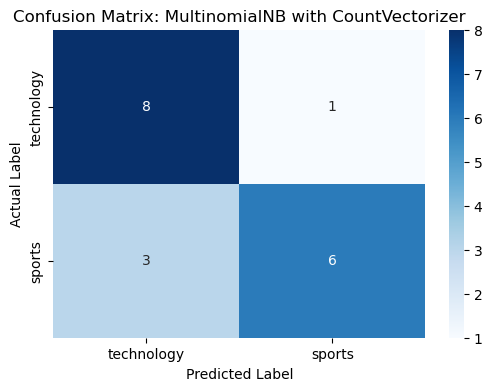


===== 实验: 使用 CountVectorizer 和 BernoulliNB 模型 =====
模型准确率 (Accuracy): 0.9444
                precision    recall  f1-score   support

technology (0)       1.00      0.89      0.94         9
    sports (1)       0.90      1.00      0.95         9

      accuracy                           0.94        18
     macro avg       0.95      0.94      0.94        18
  weighted avg       0.95      0.94      0.94        18



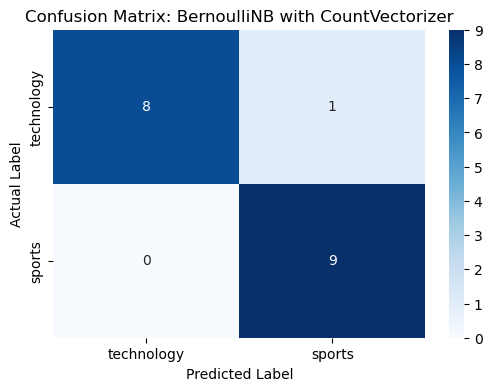


===== 实验: 使用 TfidfVectorizer 和 MultinomialNB 模型 =====
模型准确率 (Accuracy): 0.7778
                precision    recall  f1-score   support

technology (0)       0.73      0.89      0.80         9
    sports (1)       0.86      0.67      0.75         9

      accuracy                           0.78        18
     macro avg       0.79      0.78      0.78        18
  weighted avg       0.79      0.78      0.77        18



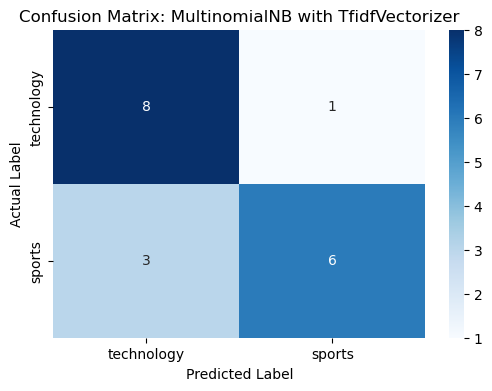


===== 实验: 使用 TfidfVectorizer 和 BernoulliNB 模型 =====
模型准确率 (Accuracy): 0.9444
                precision    recall  f1-score   support

technology (0)       1.00      0.89      0.94         9
    sports (1)       0.90      1.00      0.95         9

      accuracy                           0.94        18
     macro avg       0.95      0.94      0.94        18
  weighted avg       0.95      0.94      0.94        18



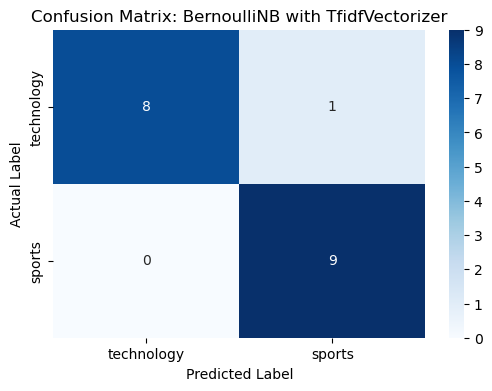

/var/folders/m8/4htghw4x28sg8j9czpx3vbq00000gn/T/ipykernel_4138/3825623073.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(x='accuracy', y='combination', data=results_df, palette='viridis')


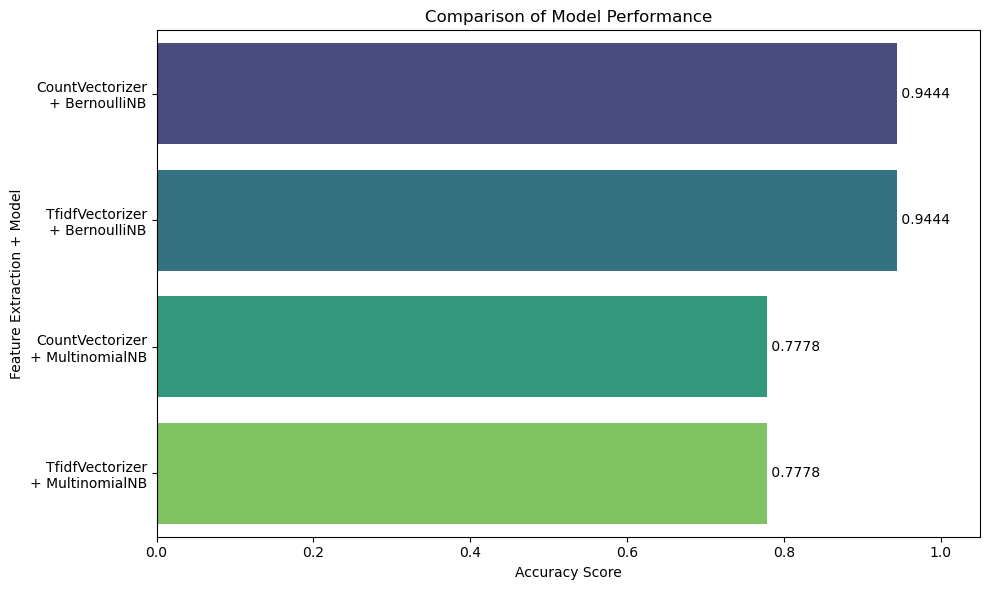

In [94]:
# --- 运行所有实验和结果柱状图 ---
results = []
results.append(train_and_evaluate_model(count_matrix, y, MultinomialNB, "CountVectorizer", "MultinomialNB"))
results.append(train_and_evaluate_model(count_matrix, y, BernoulliNB, "CountVectorizer", "BernoulliNB"))
results.append(train_and_evaluate_model(X, y, MultinomialNB, "TfidfVectorizer", "MultinomialNB"))
results.append(train_and_evaluate_model(X, y, BernoulliNB, "TfidfVectorizer", "BernoulliNB"))

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='accuracy', ascending=False) # 按准确率排序
plt.figure(figsize=(10, 6))
bar_plot = sns.barplot(x='accuracy', y='combination', data=results_df, palette='viridis')
# 在每个柱子上显示准确率数值
for index, value in enumerate(results_df['accuracy']):
    plt.text(value, index, f' {value:.4f}', va='center')
plt.xlabel('Accuracy Score')
plt.ylabel('Feature Extraction + Model')
plt.title('Comparison of Model Performance')
plt.xlim(0, 1.05) # 设置x轴范围，确保文本能显示完全
plt.tight_layout() # 调整布局
plt.show()

### 结论
**由以上实验显示，对于多项式nb和伯努利nb：**

伯努利更优。但是按理来说，对于每一个文档里的每一个特征（词）的次数应该是离散分布而不是二项分布。然而这个例子里由于数据集极小且这两个类别高度可分，导致伯努利NB的只用决定“特征词是否存在”（0-1）即可决定属于哪一类。比如：“这份文档里有‘Python’吗？有。好，那它很可能是技术类。”

**由以上实验显示，对于CountVectorizer和TfidfVectorizer：**

实验显示两者的结果几乎一样。对于伯努利NB：无论是CountVectorizer的输出（如词频为2）还是TfidfVectorizer的输出（如TF-IDF值为0.45），伯努利NB在内部处理时都会将它们视为“1”（即出现）。所以，对于伯努利NB来说，这两种特征提取方法最终给它的输入信息是等价的。
对于多项式NB：由于数据集太简单，特征词太明确，这种数值上的差异不足以改变最终的分类结果。

## 📖 CountVectorizer 与 TfidfVectorizer 讲解

**1️⃣ CountVectorizer（词频向量化）**

## 1. 它在做什么？

把一组文本（corpus）转为**稀疏的词袋矩阵**：  
- 行 = 文档（document）  
- 列 = 词项（term / token）  
- 值 = 该词在该文档中出现的**次数**（term frequency, TF）  

> 注意：CountVectorizer **不做** IDF 加权、不做归一化；只是**计数**。是否归一化、是否做 TF-IDF，由后续模块决定（如 `TfidfTransformer`）。
- 将文本转化为词袋（Bag of Words）模型。
- 每个文档表示为一个向量，元素值为该词在文档中出现的次数。
- 特点：
  - 简单直观，适合 **MultinomialNB**（假设词频服从多项分布）。
  - 对高频常用词较敏感，需要配合停用词过滤（`stop_words='english'`）。
- 示例：
  ```python
  from sklearn.feature_extraction.text import CountVectorizer
  cv = CountVectorizer(stop_words='english')
  X = cv.fit_transform(corpus)
  ```
## 2. 数学形式（Bag-of-Words）

给定词表 $V=\{t_1,\dots,t_m\}$ 和文档 $d$，CountVectorizer 输出向量 $\mathbf{x}^{(d)}\in\mathbb{N}_0^{m}$：  
$$x^{(d)}_j=\text{count}\big(t_j \text{ appears in } d\big).$$
稀疏实现：多数 $x^{(d)}_j=0$，因此采用 CSR/CSC 稀疏矩阵存储以节省内存与计算。

## 3. 典型流程（fit → transform）
1) `fit(corpus)`: 解析文本→分词/正则→统计**文档频次**（DF）→构建**词表 vocabulary**（为每个词分配索引）  
2) `transform(corpus)`: 根据词表把文本映射为**计数矩阵**  
3) `fit_transform(corpus)`: 一步完成上述两步

## 4. 关键参数（最常用）
- `stop_words`: 停用词过滤（如 `"english"` 或自定义 list）。  
- `ngram_range=(1,1)`: n-gram 范围（如 `(1,2)` 同时抽取 unigram+bigram）。  
- `min_df`, `max_df`: 过滤极稀有/极常见词（支持比例或整数）。  
  - `min_df=2`：出现在**少于2个文档**的词被过滤；  
  - `max_df=0.9`：在**≥90%**文档中出现的词被过滤。  
- `max_features`: 只保留信息量最高的 Top-K 词（按词频排序）。（稀疏矩阵上只有词频最高的多少个词）  
- `binary=False`: 若 `True` 则把计数改为**出现/未出现**（0/1）。与 **BernoulliNB** 更契合。  
- `token_pattern`: 分词的正则；默认适合英文（匹配至少两个字母/数字的“词”）。  
- `lowercase=True`: 全部小写化。  
- `analyzer="word"` / `"char"`：按词或按字符 n-gram 提取。  
- `dtype`: 输出矩阵的数据类型（默认 `np.int64`）。  
- `vocabulary`: 传入**固定词表**（例如训练集学到的词表在测试阶段复用，避免“词表漂移”）。

## 5. 与朴素贝叶斯的搭配
- **MultinomialNB** 假设特征为**计数/频数**，与 CountVectorizer **天然契合**；  
- **BernoulliNB** 倾向二值特征（出现/未出现），可：  
  - 直接用 `CountVectorizer(binary=True)`；或  
  - 用普通计数后再配合 `Binarizer` / 自定义阈值将特征二值化。



##  词 n-gram（word n-gram）就是按词为单位，取连续的 n 个词组成的片段（短语）。它用来把“词序/搭配关系”编码进特征，而不仅仅是单个词频。

* 定义

给定分词后的序列：[w1, w2, w3, ...]

unigram（1-gram）：[w1] [w2] [w3] ...

bigram（2-gram）：[w1 w2] [w2 w3] [w3 w4] ...

trigram（3-gram）：[w1 w2 w3] [w2 w3 w4] ...

例子

句子："machine learning improves accuracy"

1-gram：["machine","learning","improves","accuracy"]

2-gram：["machine learning","learning improves","improves accuracy"]

1–2-gram：两者合并（最常用）

作用与何时使用

捕捉固定搭配/短语（如 “machine learning”, “data mining”）→ 常用 (1,2)

文本短、单词歧义大 → 适度加入 bigram 可提升区分度

太大的 n 会让特征维度暴涨，需配合 min_df/max_df/max_features 控制

与“字符 n-gram”的区别

词 n-gram：基于词序列，更语义化；依赖分词质量

字符 n-gram：基于字符窗口（适合无空格语言、拼写变化鲁棒）

中文提示

需要先中文分词（jieba 等），再取词 n-gram；

若不分词，可用字符 n-gram（analyzer="char"）当近似。

In [1]:
# 6. 最小可复现（英文示例）
from sklearn.feature_extraction.text import CountVectorizer

corpus = [
    "AI improves data analysis",
    "Deep learning improves recognition",
    "Football players love training"
]

cv = CountVectorizer(stop_words="english", ngram_range=(1,2), min_df=1, max_df=1.0)
X = cv.fit_transform(corpus)

print("shape:", X.shape)  # (文档数, 词表大小)
print("vocab size:", len(cv.vocabulary_))
print("feature names (前10):", cv.get_feature_names_out()[:10])
print("row 0 vector:", X[0].toarray().ravel())


shape: (3, 20)
vocab size: 20
feature names (前10): ['ai' 'ai improves' 'analysis' 'data' 'data analysis' 'deep'
 'deep learning' 'football' 'football players' 'improves']
row 0 vector: [1 1 1 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0]


**2️⃣ TfidfVectorizer（TF-IDF 向量化）**

## 1. 它在做什么？
- **TF（词频）**：衡量词在**当前文档**中出现得多不多。
- **IDF（逆文档频率）**：衡量词在**整个语料**中常不常见（越稀有越重要）。
***核心思想：在一篇文档里常见、但在全语料里少见的词更能区分文档。***

- 在 CountVectorizer 基础上引入 **逆文档频率（IDF）**，降低常见词权重、提高稀有词重要性。
- 数学表达式：

  $ \text{TF-IDF}(t,d) = \text{TF}(t,d) \times \log\frac{N}{\text{DF}(t)} $

  这个式子表示词在特定文档中出现的次数多

其中：
  - TF：词在文档中的出现频率。
  - DF：包含该词的文档数。
  - N：总文档数。
- 特点：
  - 抑制停用词影响，增强区分性。
  - 生成稀疏矩阵，适合短文本分类、信息检索。
  - 适用于 **MultinomialNB** 和 **BernoulliNB**，但后者需二值化。
- 示例：
  ```python
  from sklearn.feature_extraction.text import TfidfVectorizer
  tfidf = TfidfVectorizer(stop_words='english')
  X = tfidf.fit_transform(corpus)
  ```

## 2. 数学定义与常见变体
设总文档数 $N$，包含词 $t$ 的文档数 $df(t)$。

**TF 选项：**
- 原始计数：$\mathrm{tf}(t,d)=\text{count}(t,d)$
- 子线性计数：$\mathrm{tf}(t,d)=1+\log \text{count}(t,d)$（若计数>0，否则0）
- 二值出现：$\mathrm{tf}(t,d)\in\{0,1\}$

**IDF 选项：**
- 经典 IDF：$\mathrm{idf}(t)=\log\frac{N}{df(t)}$
- 平滑 IDF（scikit-learn 默认）：$\displaystyle \mathrm{idf}(t) = \log\frac{1+N}{1+df(t)} + 1$

**组合：** $\mathrm{tf\!-\!idf}(t,d) = \mathrm{tf}(t,d)\times \mathrm{idf}(t)$

**归一化（重要）**：通常对文档向量做 L2 归一化（`norm='l2'`），以消除文档长度影响，并与余弦相似度契合。


### 1) 子线性计数（sublinear TF）

$$\mathrm{tf}(t,d)=\begin{cases}
1+\log(\text{count}(t,d)), & \text{count}>0 \\
0, & \text{count}=0
\end{cases}$$

**直觉**：当一个词在同一文档中反复出现时，信息增益不会线性增长；对数压缩能“给超高频词降温”。

- 单词在一篇文档里出现很多次，信息增益不会线性增长。对数压缩把超高频的“头部词”降温，避免它们“一家独大”。

- 当同一词在一篇文档里从 10 次涨到 100 次时，线性 TF 会翻 10 倍；子线性 TF 只从 1+log10 涨到 1+log100，涨幅小很多。

**何时更好**

 - 文档长度差异大、或存在口号式重复、刷词的文本（营销文案、论坛水文、垃圾邮件）。

 - 做检索/聚类/分类时，希望“出现过且适度频繁”的词更重要，但不鼓励极端重复。

**适用场景**：长文档、存在重复/刷词、营销文案、论坛水文等；检索/聚类/分类等任务。

**实现提示（scikit-learn）**：

- TfidfVectorizer(sublinear_tf=True) 或 TfidfTransformer(sublinear_tf=True)。

- 日志底数无关紧要（只差常数因子）；库实现用自然对数。


### 2) IDF（逆文档频率）


**经典 IDF**

**定义：**  
$
\mathrm{idf}(t)=\log \frac{N}{df(t)},
$
其中 \(N\) 是总文档数，\(df(t)\) 是包含词 \(t\) 的文档数。

**直觉：**
- 词在全语料越**稀有**（\(df\) 小），IDF 越大 → 权重越高；
- 词在几乎每篇文档都出现（**常用词**），IDF 接近 0 → 权重被压低。

**注意：**
- 当 \(df = N\) 时，$\log \frac{N}{N}=0$，该词被“归零化”在 IDF 这部分。  
- 为避免数值/零除问题，实践里常用**平滑 IDF**：

  $
  \log \frac{1+N}{1+df(t)} + 1.
  $
  
- 若此处需要强调“经典”公式，则用 $\log \frac{N}{df(t)}$ 来理解其机制即可。


## 3. scikit-learn 两种用法
### (A) 一步完成：`TfidfVectorizer`
- `ngram_range=(1,1)`：n-gram 范围（如 `(1,2)` 加入二元短语）
- `min_df` / `max_df`：过滤稀有/泛滥词
- `stop_words='english'`：停用词
- `use_idf=True`：是否乘以 IDF
- `smooth_idf=True`：平滑 IDF（默认）
- `sublinear_tf=False`：是否使用 `1+log(tf)`
- `norm='l2'`：文档向量归一化方式（`'l1'`/`None`）
- `analyzer='word'|'char'|'char_wb'`：按词/字符提特征

### (B) 两步串联：`CountVectorizer` + `TfidfTransformer`
便于把计数特征与其他步骤解耦。



In [3]:
# 示例：(A) 直接用 TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = [
    "machine learning applications",
    "applications in sports analytics",
    "deep learning for image recognition"
]

tfidf = TfidfVectorizer(stop_words="english",
                        ngram_range=(1,2),
                        min_df=1, max_df=1.0,
                        sublinear_tf=True,
                        smooth_idf=True,
                        norm="l2")
X = tfidf.fit_transform(corpus)
print("shape:", X.shape)
print("vocab size:", len(tfidf.vocabulary_))
print("sample features:", tfidf.get_feature_names_out()[:10])


shape: (3, 15)
vocab size: 15
sample features: ['analytics' 'applications' 'applications sports' 'deep' 'deep learning'
 'image' 'image recognition' 'learning' 'learning applications'
 'learning image']


**3️⃣ 对比总结：**
| 特征类型 | 特征含义 | 适用模型 | 优点 | 缺点 |
|-----------|------------|------------|----------|----------|
| CountVectorizer | 词出现次数 | MultinomialNB | 简单直观，信息完整 | 对高频词敏感 |
| TfidfVectorizer | 词重要性权重 | MultinomialNB / BernoulliNB | 降噪能力强，特征区分性高 | 稀疏矩阵、需调参 |